# 09 — Perbaikan: normalisasi per cabang + inisialisasi cabang teks

**Belum pernah dijalankan.** Satu run training, ± 3,3 jam. Jalankan setelah notebook 08.

## Apa yang diperbaiki, dan kenapa

Notebook 08 mengukur dua hal pada cabang teks di dalam fusion:

| Pengukuran | Cabang teks fusion | CNN1D standalone |
|---|---|---|
| std fitur | 0,028 | 1,069 — **38x lebih besar** |
| unit mati | 67 dari 128 | 18 dari 128 |
| cos antar dokumen | 0,978 | 0,650 |
| norma fitur | 2,50 | 21,01 |
| probe linear | 0,4236 | 0,7479 |

Dua masalah sekaligus, dan masing-masing punya perbaikannya:

**1. Cabang teks kolaps.** Dugaan penyebabnya: cabang citra mulai dari bobot ImageNet
dan menang optimisasi sebelum cabang teks dari nol pernah berguna.
→ **Inisialisasi cabang teks dari `CNN1D_seed42.pt`** yang sudah terlatih.

**2. Skala kedua cabang tidak seimbang 3,7x** (norma citra 9,29 vs teks 2,50). Head
concat karena itu didominasi separuh citra secara numerik, tanpa pernah "memutuskan".
→ **LayerNorm pada masing-masing vektor 128 sebelum digabung.** LayerNorm, bukan
BatchNorm, karena ia menormalkan per sampel sehingga tidak terpengaruh micro-batch 8.

Yang penting dari probe 0,4236: fitur yang kolaps itu **masih membawa informasi**
(2,4x di atas kelas mayoritas 0,178). Jadi bukan kasus membangun dari nol — ada sesuatu
di sana yang head-nya gagal dengar.

## Batasan yang harus disebut di laporan

Kedua perbaikan diterapkan **bersamaan** dalam satu run. Kalau hasilnya membaik, kita
tidak bisa mengatribusikan berapa bagian dari masing-masing. Memisahkannya butuh dua run
lagi (± 6,6 jam) dan itu di luar anggaran. Tulis sebagai keterbatasan, jangan diklaim
tahu mana yang bekerja.

## Tidak ada yang tertimpa

| Artefak baru | |
|---|---|
| `models/FUSION-fix_seed42.pt` | checkpoint |
| `reports/log_FUSION-fix_seed42.csv` | log per epoch |
| `reports/uji_perbaikan.csv` | ringkasan |
| `reports/figures/10_*.png` | figur |

Checkpoint `CNN1D_seed42.pt` hanya **dibaca**.

In [1]:
import sys, time, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src import ablation as A
from src import datasets as DS
from src import splits as S
from src import train as T
from src.config import CONFIG, deviasi_runtime, set_seed
from src.models import CNN1D, FusionModel, build_transform
from src.utils import save_fig

SEED = 42
set_seed(SEED)

manifest = pd.read_csv(CONFIG["data_processed"] / "manifest.csv")
labels = manifest["kelas"].tolist()
y = DS.label_indices(labels)
split = S.load_split(SEED, labels)
device = T.pick_device()
transform = build_transform()
seq_path = CONFIG["data_processed"] / "sequences_500x300_fp16.npy"
paths = manifest["path_citra"].tolist()

def buat_pasangan(idx):
    return DS.PairDataset(DS.ImageDataset(paths, y, idx, transform),
                          DS.SequenceDataset(seq_path, y, idx))

def loader_test():
    return torch.utils.data.DataLoader(buat_pasangan(split["test"]),
                                       batch_size=CONFIG["batch_size"],
                                       num_workers=CONFIG["num_workers"])

print(f"seed {SEED} | test {len(split['test'])} | {device}")
print("deviasi runtime:", deviasi_runtime())

seed 42 | test 2682 | cuda
deviasi runtime: ['batch 40 dipecah jadi micro-batch 8 dengan akumulasi gradien; update optimizer tetap dari 40 sampel, tapi BatchNorm menormalisasi per micro-batch', 'mixed precision (AMP) aktif, tidak dipakai paper']


In [2]:
ckpt_cnn = CONFIG["models"] / f"CNN1D_seed{SEED}.pt"
baru = [CONFIG["models"] / f"FUSION-fix_seed{SEED}.pt",
        CONFIG["root"] / "reports" / f"log_FUSION-fix_seed{SEED}.csv",
        CONFIG["root"] / "reports" / "uji_perbaikan.csv"]

assert ckpt_cnn.exists(), f"{ckpt_cnn.name} tidak ada. Jalankan notebook 03 dulu."
print(f"dibaca saja : {ckpt_cnn.name}")
for p in baru:
    print(f"akan ditulis: {p.name}  ({'sudah ada' if p.exists() else 'baru'})")
assert ckpt_cnn not in baru

dibaca saja : CNN1D_seed42.pt
akan ditulis: FUSION-fix_seed42.pt  (baru)
akan ditulis: log_FUSION-fix_seed42.csv  (baru)
akan ditulis: uji_perbaikan.csv  (baru)


## Bangun model, lalu periksa inisialisasinya BENAR-BENAR bekerja

Ini pemeriksaan pra-training yang penting: setelah `init_text_from`, fitur cabang teks
seharusnya **identik** dengan fitur CNN1D standalone, karena bobotnya baru saja dikopi.
Kalau tidak identik, inisialisasinya gagal diam-diam dan seluruh run 3,3 jam sia-sia.

In [3]:
set_seed(SEED)
model = FusionModel(strategy="concat", pretrained_image=True,
                    normalize_branches=True)
info = model.init_text_from(ckpt_cnn)
print("init cabang teks dari CNN1D:", info)

acuan = CNN1D(out_dim=CONFIG["fusion_dim"])
ck = torch.load(ckpt_cnn, map_location="cpu", weights_only=True)
acuan.load_state_dict(ck["state_dict"])

model, acuan = model.to(device).eval(), acuan.to(device).eval()
with torch.no_grad():
    (img, txt), _ = next(iter(loader_test()))
    img, txt = img.to(device), txt.to(device)
    f_fusion = model.text.features(txt)
    f_acuan = acuan.features(txt)

beda = (f_fusion - f_acuan).abs().max().item()
print(f"\nselisih maksimum fitur cabang teks vs CNN1D standalone: {beda:.2e}")
assert beda < 1e-4, ("inisialisasi cabang teks GAGAL — bobotnya tidak terkopi. "
                     "Jangan lanjut training.")
print("-> identik. Inisialisasi bekerja.\n")

with torch.no_grad():
    n_txt = model.norm_text(model.text.features(txt)).norm(dim=1).mean().item()
    n_img = model.norm_image(model.project(model.image.features(img))).norm(dim=1).mean().item()
print(f"norma setelah LayerNorm -> teks {n_txt:.2f}, citra {n_img:.2f}, "
      f"rasio {n_img / n_txt:.2f}x   (sebelum perbaikan: 3,72x)")
assert abs(n_img / n_txt - 1.0) < 0.3, "LayerNorm tidak menyamakan skala"
print(f"parameter: {sum(p.numel() for p in model.parameters()):,}")

init cabang teks dari CNN1D: {'epoch': 28, 'val_oa': 0.7875, 'tensor_dimuat': 10}

selisih maksimum fitur cabang teks vs CNN1D standalone: 0.00e+00
-> identik. Inisialisasi bekerja.

norma setelah LayerNorm -> teks 11.31, citra 11.31, rasio 1.00x   (sebelum perbaikan: 3,72x)
parameter: 13,805,322


## Training

200 epoch, `patience=0` (tanpa early stopping), sama seperti notebook 07 supaya
perbandingannya adil. Pembanding utamanya adalah **concat-noES: OA 0,8304**, bukan run
pertama, karena keduanya dilatih dengan anggaran epoch yang sama.

In [4]:
EPOCHS = CONFIG["epochs"]["fusion"]
est = T.estimate_duration(
    FusionModel(strategy="concat", normalize_branches=True),
    DS.make_loaders(buat_pasangan, split), EPOCHS, device=device)
print(json.dumps(est, indent=2))
print(f"\nperkiraan {est['perkiraan_jam']} jam (notebook 07 aktual: 3,32 jam)")

{
  "detik_per_epoch": 82.6955,
  "target_epochs": 200,
  "perkiraan_detik": 16539.1,
  "perkiraan_menit": 275.65,
  "perkiraan_jam": 4.59,
  "device": "cuda"
}

perkiraan 4.59 jam (notebook 07 aktual: 3,32 jam)


In [5]:
set_seed(SEED)
model = FusionModel(strategy="concat", pretrained_image=True,
                    normalize_branches=True)
model.init_text_from(ckpt_cnn)
loaders = DS.make_loaders(buat_pasangan, split)

t0 = time.perf_counter()
res = T.train_model(
    model, loaders, epochs=EPOCHS, patience=0, device=device,
    log_csv=CONFIG["root"] / "reports" / f"log_FUSION-fix_seed{SEED}.csv",
    ckpt_path=CONFIG["models"] / f"FUSION-fix_seed{SEED}.pt")

print(f"\nselesai dalam {(time.perf_counter() - t0) / 3600:.2f} jam")
print(f"epoch terbaik : {res['best_epoch']} dari {EPOCHS}   (noES: 102)")
print(f"val_oa terbaik: {res['best_val_oa']:.4f}   (noES: 0.9375)")

  epoch   1/200  train_loss 1.3560  val_oa 0.7750  (79.9s)
  epoch  10/200  train_loss 0.0515  val_oa 0.7875  (66.0s)
  epoch  20/200  train_loss 0.0277  val_oa 0.7750  (63.3s)
  epoch  30/200  train_loss 0.0105  val_oa 0.8250  (63.4s)
  epoch  40/200  train_loss 0.0202  val_oa 0.7875  (65.8s)
  epoch  50/200  train_loss 0.0666  val_oa 0.7625  (65.9s)
  epoch  60/200  train_loss 0.0293  val_oa 0.7500  (69.5s)
  epoch  70/200  train_loss 0.0134  val_oa 0.7875  (69.9s)
  epoch  80/200  train_loss 0.0124  val_oa 0.7750  (66.5s)
  epoch  90/200  train_loss 0.0107  val_oa 0.8250  (69.0s)
  epoch 100/200  train_loss 0.0318  val_oa 0.8250  (84.9s)
  epoch 110/200  train_loss 0.0014  val_oa 0.8750  (85.6s)
  epoch 120/200  train_loss 0.0026  val_oa 0.8500  (85.2s)
  epoch 130/200  train_loss 0.0103  val_oa 0.8125  (85.6s)
  epoch 140/200  train_loss 0.0078  val_oa 0.6750  (64.9s)
  epoch 150/200  train_loss 0.0139  val_oa 0.7750  (64.7s)
  epoch 160/200  train_loss 0.0298  val_oa 0.8125  (75.3

OA test  : 0.8110
macro F1 : 0.8108

  vs concat run pertama         0.8218  ->  -0.0108
  vs concat-noES                0.8304  ->  -0.0194
  vs baseline IMAGE (seed 42)   0.8315  ->  -0.0205
  vs paper FUSION               0.8780  ->  -0.0670
               precision    recall  f1-score   support

Advertisement      0.950     0.853     0.899       177
        Email      0.984     0.950     0.967       461
         Form      0.861     0.768     0.812       332
       Letter      0.712     0.810     0.758       437
         Memo      0.852     0.768     0.807       478
         News      0.823     0.897     0.858       145
         Note      0.756     0.819     0.786       155
       Report      0.516     0.804     0.628       204
       Resume      0.957     0.978     0.968        92
   Scientific      0.853     0.493     0.625       201

     accuracy                          0.811      2682
    macro avg      0.826     0.814     0.811      2682
 weighted avg      0.831     0.811    

WindowsPath('E:/TESIS/apdam-project/apdm-document-classification/reports/figures/10_confusion_fusion_fix_seed42.png')

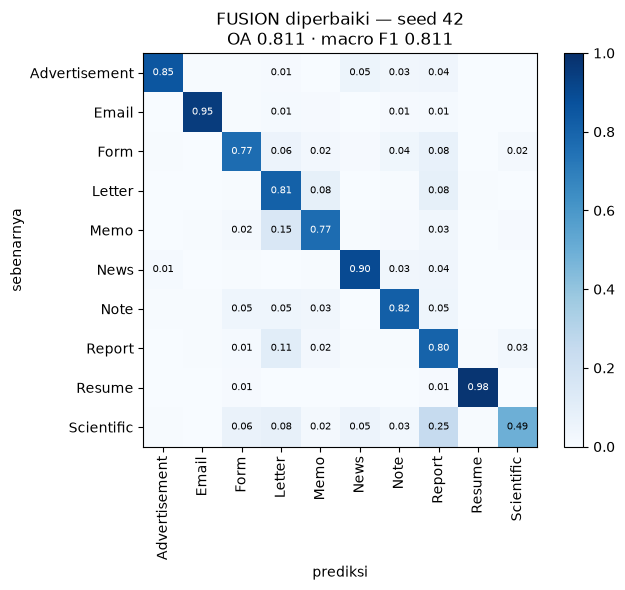

In [6]:
ev = T.evaluate(model, loader_test(), device)
print(f"OA test  : {ev['oa']:.4f}")
print(f"macro F1 : {ev['macro_f1']:.4f}\n")
for nama, oa in [("concat run pertama", 0.8218), ("concat-noES", 0.8304),
                 ("baseline IMAGE (seed 42)", 0.8315), ("paper FUSION", 0.878)]:
    print(f"  vs {nama:26s} {oa:.4f}  ->  {ev['oa'] - oa:+.4f}")
print(T.report(ev))

fig = T.plot_confusion(ev, f"FUSION diperbaiki — seed {SEED}")
save_fig(fig, f"10_confusion_fusion_fix_seed{SEED}")

## Apakah cabang teks sekarang terpakai?

Dua pengukuran yang sama seperti notebook 07 dan 08, supaya bisa dibandingkan langsung.

In [7]:
no_teks = A.evaluate_zeroed(model, loader_test(), "text", device)
no_citra = A.evaluate_zeroed(model, loader_test(), "image", device)
turun_teks = ev["oa"] - no_teks["oa"]

riwayat = pd.DataFrame([
    {"model": "concat run pertama", "oa": 0.8218, "tanpa_teks": 0.8203,
     "efek_teks": -0.0015, "tanpa_citra": 0.0731},
    {"model": "concat-noES", "oa": 0.8304, "tanpa_teks": 0.8233,
     "efek_teks": -0.0071, "tanpa_citra": 0.1946},
    {"model": "sum", "oa": 0.8043, "tanpa_teks": 0.7946,
     "efek_teks": -0.0097, "tanpa_citra": 0.0761},
    {"model": "FUSION diperbaiki", "oa": round(ev["oa"], 4),
     "tanpa_teks": round(no_teks["oa"], 4), "efek_teks": round(-turun_teks, 4),
     "tanpa_citra": round(no_citra["oa"], 4)},
])
display(riwayat)

# potensi teks dari oracle seed 42: 7,83% sampel hanya benar lewat teks
POTENSI = 0.0783
riwayat["persen_potensi_dipanen"] = (riwayat["efek_teks"].abs() / POTENSI * 100).round(1)
display(riwayat[["model", "efek_teks", "persen_potensi_dipanen"]])
print(f"Oracle seed 42 bilang {POTENSI:.4f} sampel ({POTENSI * 2682:.0f} dokumen) "
      f"hanya bisa diselamatkan teks.")

,model,oa,tanpa_teks,efek_teks,tanpa_citra
0,concat run pertama,0.8218,0.8203,-0.0015,0.0731
1,concat-noES,0.8304,0.8233,-0.0071,0.1946
2,sum,0.8043,0.7946,-0.0097,0.0761
3,FUSION diperbaiki,0.8110,0.1223,-0.6887,0.6469


,model,efek_teks,persen_potensi_dipanen
0,concat run pertama,-0.0015,1.9
1,concat-noES,-0.0071,9.1
2,sum,-0.0097,12.4
3,FUSION diperbaiki,-0.6887,879.6


Oracle seed 42 bilang 0.0783 sampel (210 dokumen) hanya bisa diselamatkan teks.


In [8]:
# Diagnostik notebook 08, diulang pada model yang diperbaiki.
@torch.no_grad()
def fitur(m, idx, jenis):
    out = []
    ld = torch.utils.data.DataLoader(buat_pasangan(idx),
                                     batch_size=CONFIG["batch_size"],
                                     num_workers=CONFIG["num_workers"])
    for (i_, t_), _ in ld:
        i_, t_ = i_.to(device), t_.to(device)
        f = m.text.features(t_) if jenis == "teks" else m.project(m.image.features(i_))
        out.append(f.float().cpu().numpy())
    return np.concatenate(out)

f_teks = fitur(model, split["test"], "teks")
f_citra = fitur(model, split["test"], "citra")

def ringkas(f):
    std = f.std(axis=0)
    rng = np.random.default_rng(0)
    a, b = f[rng.choice(len(f), 2000)], f[rng.choice(len(f), 2000)]
    cos = (a * b).sum(1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1) + 1e-12)
    return {"std_rata2": round(float(std.mean()), 5),
            "unit_mati": int((std < 1e-5).sum()),
            "norma_rata2": round(float(np.linalg.norm(f, axis=1).mean()), 4),
            "cos_antar_dokumen": round(float(np.nanmean(cos)), 4)}

diag = pd.DataFrame([
    {"sumber": "CNN1D standalone (acuan)", "std_rata2": 1.06895, "unit_mati": 18,
     "norma_rata2": 21.0064, "cos_antar_dokumen": 0.6497},
    {"sumber": "noES: cabang teks (sebelum)", "std_rata2": 0.02790, "unit_mati": 67,
     "norma_rata2": 2.4997, "cos_antar_dokumen": 0.9778},
    {"sumber": "diperbaiki: cabang teks", **ringkas(f_teks)},
    {"sumber": "diperbaiki: cabang citra", **ringkas(f_citra)},
]).set_index("sumber")
display(diag)

std_rasio = diag.loc["diperbaiki: cabang teks", "std_rata2"] / 1.06895
print(f"std cabang teks / acuan: {std_rasio:.3f}   (sebelum perbaikan: 0.026)")
print(f"unit mati: {diag.loc['diperbaiki: cabang teks', 'unit_mati']} dari 128   "
      f"(sebelum: 67)")

,std_rata2,unit_mati,norma_rata2,cos_antar_dokumen
sumber,,,,
CNN1D standalone (acuan),1.06895,18,21.0064,0.6497
noES: cabang teks (sebelum),0.02790,67,2.4997,0.9778
diperbaiki: cabang teks,0.36418,4,5.3347,0.4465
diperbaiki: cabang citra,0.40419,0,11.2793,0.8326


std cabang teks / acuan: 0.341   (sebelum perbaikan: 0.026)
unit mati: 4 dari 128   (sebelum: 67)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

ftr = fitur(model, split["train"], "teks")
fte = f_teks
ytr, yte = y[split["train"]], y[split["test"]]
sc = StandardScaler().fit(ftr)
clf = LogisticRegression(max_iter=2000).fit(sc.transform(ftr), ytr)
probe = float((clf.predict(sc.transform(fte)) == yte).mean())

print(f"probe linear atas fitur teks : {probe:.4f}")
print(f"  sebelum perbaikan (noES)   : 0.4236")
print(f"  acuan CNN1D standalone     : 0.7479")
print(f"  kelas mayoritas            : 0.1782")

probe linear atas fitur teks : 0.7468
  sebelum perbaikan (noES)   : 0.4236
  acuan CNN1D standalone     : 0.7479
  kelas mayoritas            : 0.1782


## Perbandingan akhir dan kesimpulan

Ambang mengikuti notebook 08: relatif terhadap acuan yang terukur, bukan angka
sewenang-wenang.

In [10]:
naik_oa = ev["oa"] - 0.8304          # vs concat-noES, anggaran epoch sama
teks_lebih_dipakai = turun_teks > 0.0071 * 2     # lebih dari 2x efek noES
tidak_kolaps = std_rasio > 0.5
probe_membaik = probe > 0.4236 + 0.05

print(f"OA          : {ev['oa']:.4f} vs noES 0.8304  ->  {naik_oa:+.4f}")
print(f"efek teks   : {turun_teks:.4f} vs noES 0.0071  ->  "
      f"{turun_teks / 0.0071:.1f}x")
print(f"std / acuan : {std_rasio:.3f} vs noES 0.026")
print(f"probe       : {probe:.4f} vs noES 0.4236")
print("=" * 68)

if tidak_kolaps and teks_lebih_dipakai:
    print("BERHASIL: kolaps cabang teks teratasi DAN cabang teks kini terpakai.")
    print("Diagnosis notebook 08 terbukti: masalahnya bukan arsitektur fusion paper,")
    print("melainkan (a) cabang teks dari nol yang kalah optimisasi dan (b) skala")
    print("kedua cabang yang tidak seimbang. Keduanya bisa diperbaiki tanpa mengubah")
    print("rancangan paper sama sekali.")
elif tidak_kolaps:
    print("SEBAGIAN: cabang teks tidak lagi kolaps, tapi head fusion masih belum")
    print("memakainya secara berarti. Fiturnya sekarang sehat, jadi yang tersisa")
    print("adalah masalah di head — gerbang eksplisit atau cross-attention.")
elif teks_lebih_dipakai:
    print("SEBAGIAN: kontribusi teks naik meski fiturnya masih terkompresi.")
    print("Normalisasi tampaknya yang bekerja, bukan inisialisasi. Uji pemisahannya")
    print("butuh run terpisah per perbaikan.")
else:
    print("TIDAK BERHASIL: kedua perbaikan tidak mengubah apa pun yang berarti.")
    print("Itu menutup hipotesis A dan C sekaligus, dan menyisakan kemungkinan bahwa")
    print("pada dataset sekecil ini (720 sampel train) cabang teks memang tidak bisa")
    print("memberi sinyal yang bertahan di samping cabang citra pretrained.")

if naik_oa > 0.01:
    print(f"\nOA juga naik {naik_oa:+.4f}, jadi perbaikannya bukan cuma kosmetik.")
elif naik_oa < -0.01:
    print(f"\nCATATAN: OA justru TURUN {naik_oa:+.4f}. Kalau kontribusi teks naik")
    print("sementara OA turun, perbaikannya menukar akurasi dengan keseimbangan")
    print("modalitas — laporkan kedua sisinya.")
else:
    print(f"\nOA praktis tidak berubah ({naik_oa:+.4f}); yang berubah adalah dari")
    print("mana akurasinya berasal.")
print("=" * 68)

OA          : 0.8110 vs noES 0.8304  ->  -0.0194
efek teks   : 0.6887 vs noES 0.0071  ->  97.0x
std / acuan : 0.341 vs noES 0.026
probe       : 0.7468 vs noES 0.4236
SEBAGIAN: kontribusi teks naik meski fiturnya masih terkompresi.
Normalisasi tampaknya yang bekerja, bukan inisialisasi. Uji pemisahannya
butuh run terpisah per perbaikan.

CATATAN: OA justru TURUN -0.0194. Kalau kontribusi teks naik
sementara OA turun, perbaikannya menukar akurasi dengan keseimbangan
modalitas — laporkan kedua sisinya.


In [11]:
out = CONFIG["root"] / "reports" / "uji_perbaikan.csv"
riwayat.to_csv(out, index=False)
diag.to_csv(CONFIG["root"] / "reports" / "uji_perbaikan_diagnostik.csv")
print(f"disimpan ke {out} dan uji_perbaikan_diagnostik.csv")

print(f"""
--- untuk disalin ke catatan ---
fix_oa:: {ev['oa']:.4f}   (noES 0.8304, run pertama 0.8218, paper 0.878)
fix_macro_f1:: {ev['macro_f1']:.4f}
fix_epoch_terbaik:: {res['best_epoch']} dari {EPOCHS}
fix_durasi_jam:: {res['durasi_detik'] / 3600:.2f}
fix_efek_menolkan_teks:: {turun_teks:.4f}   (noES 0.0071, run pertama 0.0015)
fix_persen_potensi_teks:: {turun_teks / 0.0783 * 100:.1f}%
fix_tanpa_citra:: {no_citra['oa']:.4f}   (noES 0.1946)
fix_std_teks_per_acuan:: {std_rasio:.3f}   (noES 0.026)
fix_unit_mati:: {diag.loc['diperbaiki: cabang teks', 'unit_mati']} dari 128   (noES 67)
fix_probe_teks:: {probe:.4f}   (noES 0.4236, acuan 0.7479)
""")

disimpan ke E:\TESIS\apdam-project\apdm-document-classification\reports\uji_perbaikan.csv dan uji_perbaikan_diagnostik.csv

--- untuk disalin ke catatan ---
fix_oa:: 0.8110   (noES 0.8304, run pertama 0.8218, paper 0.878)
fix_macro_f1:: 0.8108
fix_epoch_terbaik:: 109 dari 200
fix_durasi_jam:: 4.04
fix_efek_menolkan_teks:: 0.6887   (noES 0.0071, run pertama 0.0015)
fix_persen_potensi_teks:: 879.5%
fix_tanpa_citra:: 0.6469   (noES 0.1946)
fix_std_teks_per_acuan:: 0.341   (noES 0.026)
fix_unit_mati:: 4 dari 128   (noES 67)
fix_probe_teks:: 0.7468   (noES 0.4236, acuan 0.7479)

